# Project 3: Reinforcement Learning Agent for Lunar Landing

**Subject:** Deep Learning and Reinforcement Learning  
**Programme:** M.Tech  
**Environment:** OpenAI Gymnasium `LunarLander-v2` (Box2D)  

---

## Abstract

In this project we train an autonomous agent to land a lunar module safely on a
designated landing pad. The task is modelled as a **Markov Decision Process (MDP)**
and solved with three approaches of increasing sophistication:

1. **Random agent** &mdash; an uninformed baseline that samples actions uniformly.
2. **Tabular Q-learning** &mdash; classical value iteration on a *discretized* version of the
   continuous state space.
3. **Deep Q-Network (DQN)** &mdash; a neural function approximator with experience replay and a
   target network, operating directly on the continuous state.

The environment is considered **solved** when the agent achieves an **average reward of
at least +200 over 100 consecutive episodes**.

> **Platform note:** This notebook is written to run on **Google Colab**. Box2D requires
> SWIG to build, so the first cell installs the dependencies. On Colab a **runtime restart
> is sometimes required** after installing Box2D &mdash; if the `gymnasium` import fails,
> use *Runtime &rarr; Restart runtime* and then re-run from the imports cell.

## 0. Colab Setup &mdash; Install Box2D dependencies

`LunarLander` lives in the Box2D family of Gymnasium environments. Box2D is a C++
physics engine whose Python bindings are compiled with **SWIG**, so we install `swig`
*before* `gymnasium[box2d]`. If you have already run this once in the current runtime you
can skip it.

In [1]:
# --- Colab dependency installation -------------------------------------------
# swig is a build-time dependency: the Box2D python bindings are generated by it.
!pip install swig -q
# gymnasium[box2d] pulls in the LunarLander / CarRacing / BipedalWalker family.
!pip install "gymnasium[box2d]" -q
# NOTE: On Colab, if the 'import gymnasium' cell below throws a Box2D error,
#       restart the runtime (Runtime -> Restart runtime) and re-run from imports.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.2 MB/s eta 0:00:00


## Imports and Reproducibility

We import the scientific stack (NumPy, Matplotlib), TensorFlow/Keras for the DQN, and
Gymnasium for the environment. All random number generators are seeded with **42** so
that results are reproducible across runs (note: Box2D physics and TF GPU kernels can
still introduce tiny non-determinism, but the seeds keep runs broadly comparable).

In [2]:
import random                       # python's built-in RNG (used by epsilon-greedy)
import numpy as np                  # numerical arrays and vectorised math
import matplotlib.pyplot as plt     # all plotting in the notebook
from collections import deque       # O(1) append/pop -> ideal for the replay buffer

# Guard the Box2D import so a missing dependency gives a clear, actionable message.
try:
    import gymnasium as gym         # the modern maintained fork of OpenAI Gym
except Exception as e:              # broad except: surface any import/build failure
    raise ImportError(
        'gymnasium import failed. On Colab, run the install cell then '
        'Runtime -> Restart runtime and re-run. Original error: ' + str(e)
    )

import tensorflow as tf             # DQN function approximator backend
from tensorflow import keras        # high-level model API
from tensorflow.keras import layers # Dense layers for the Q-network

# --- Reproducibility: seed every RNG we rely on ------------------------------
SEED = 42                           # single source of truth for the seed
random.seed(SEED)                   # seeds python's random (epsilon-greedy coin flips)
np.random.seed(SEED)                # seeds numpy (buffer sampling, noise)
tf.random.set_seed(SEED)            # seeds tensorflow weight init and dropout

print('TensorFlow version :', tf.__version__)
print('Gymnasium version  :', gym.__version__)
print('GPU available      :', bool(tf.config.list_physical_devices('GPU')))

TensorFlow version : 2.20.0
Gymnasium version  : 1.3.0
GPU available      : True


## Global Configuration Cell (tunable knobs)

Full RL training is slow, so every expensive quantity is exposed here as a **named knob**.
The defaults are chosen to **run in a reasonable Colab session** while still demonstrating
learning. Higher values give better results &mdash; the comments say by how much.

> **To actually solve the environment (avg reward >= +200):** raise `N_EPISODES_DQN` to
> ~600&ndash;800 and `N_EPISODES_Q` to ~5000+. The defaults below prioritise runnability.

In [3]:
# ============================================================================
#  GLOBAL CONFIGURATION  -- tune these knobs to trade runtime for performance
# ============================================================================

# Try the classic env id first; newer gymnasium renamed it to v3.
def make_env(render_mode=None):
    """Create a LunarLander environment, tolerating the v2 -> v3 rename.

    Gymnasium >= 1.0 ships LunarLander-v3; older releases use v2. We attempt v2
    first (as specified by the project brief) and fall back to v3 so the notebook
    runs on whatever version Colab currently pins.
    """
    for env_id in ('LunarLander-v2', 'LunarLander-v3'):     # preferred order
        try:
            return gym.make(env_id, render_mode=render_mode)  # succeeds -> return
        except Exception:                                     # id not registered
            continue                                          # try the next id
    raise RuntimeError('Neither LunarLander-v2 nor v3 could be created.')

# ---- Episode / step budgets -------------------------------------------------
N_EPISODES_RANDOM = 100    # random baseline episodes (brief requires 100)
N_EPISODES_Q      = 1500   # tabular Q-learning episodes; more is better (5000+ ideal)
N_EPISODES_DQN    = 400    # DQN training episodes; ~500-700 typically nears +200
MAX_STEPS         = 100  # per-episode step cap (LunarLander also truncates ~100)
EVAL_EPISODES     = 20     # greedy evaluation episodes for the trained DQN

# ---- Shared RL hyperparameters ----------------------------------------------
GAMMA = 0.99               # discount factor: near 1 because the big reward is terminal
SOLVED_THRESHOLD = 200.0   # avg reward over 100 episodes that counts as 'solved'
MOVING_AVG_WINDOW = 100    # window for the 100-episode moving average

print('Config loaded. DQN episodes =', N_EPISODES_DQN, '| Q episodes =', N_EPISODES_Q)

Config loaded. DQN episodes = 400 | Q episodes = 1500


# Task 1 - Environment Setup and Exploration

We initialise the environment, document its state and action spaces, and measure a
**random-agent baseline** so that later agents can be judged against a meaningful
lower bound.

In [4]:
# Create the environment and inspect its spaces.
env = make_env()                                  # headless (render_mode=None)

state_dim = int(env.observation_space.shape[0])        # 8 continuous observation variables
n_actions = int(env.action_space.n)                    # 4 discrete actions

print('Observation space :', env.observation_space)   # Box(8,) continuous
print('  -> dimensions    :', state_dim)
print('Action space      :', env.action_space)        # Discrete(4)
print('  -> n_actions     :', n_actions)

# Sample bounds reported by gymnasium (some are +/-inf for velocities).
print('\nObservation low  :', env.observation_space.low)
print('Observation high :', env.observation_space.high)

Observation space : Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  -> dimensions    : 8
Action space      : Discrete(4)
  -> n_actions     : 4

Observation low  : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
Observation high : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


## 1.1 The MDP: state, actions and reward

### State space &mdash; 8 continuous variables
The observation is a vector `s = [x, y, vx, vy, theta, omega, leg_L, leg_R]`:

| Idx | Variable | Meaning | Typical range |
|-----|----------|---------|---------------|
| 0 | `x` | horizontal position (0 = centre of pad) | ~[-1.5, 1.5] |
| 1 | `y` | vertical position (0 = pad height) | ~[-1.5, 1.5] |
| 2 | `vx` | horizontal velocity | ~[-5, 5] |
| 3 | `vy` | vertical velocity | ~[-5, 5] |
| 4 | `theta` | lander angle (radians) | ~[-3.14, 3.14] |
| 5 | `omega` | angular velocity | ~[-5, 5] |
| 6 | `leg_L` | left leg ground contact (boolean) | {0, 1} |
| 7 | `leg_R` | right leg ground contact (boolean) | {0, 1} |

The first six are **continuous**; the last two are **binary** contact flags.

### Action space &mdash; `Discrete(4)`
| Action | Effect |
|--------|--------|
| 0 | do nothing (coast) |
| 1 | fire **left** orientation engine |
| 2 | fire **main** (downward) engine |
| 3 | fire **right** orientation engine |

### Reward structure
- **Shaping reward** for moving toward the pad / slowing down / staying upright.
- **+10** per leg that makes ground contact.
- **-0.03** per frame the side engines fire, **-0.3** per frame the main engine fires
  (a **fuel penalty** that discourages needless thrust).
- **+100** for a safe landing, **-100** for a crash.
- An episode scoring **>= +200** is a clean, fuel-efficient landing.

In [5]:
def run_random_agent(env, n_episodes, max_steps, seed=SEED):
    """Run a uniformly-random policy and return the per-episode total reward.

    Args:
        env:        a gymnasium environment.
        n_episodes: number of episodes to roll out.
        max_steps:  safety cap on steps per episode.
        seed:       base seed; each episode is seeded seed+episode for variety.

    Returns:
        list[float]: total (undiscounted) reward for each episode.
    """
    rewards = []                                        # collect one score per episode
    for ep in range(n_episodes):                        # loop over episodes
        state, _ = env.reset(seed=seed + ep)            # reset; vary seed per episode
        total = 0.0                                     # accumulate reward this episode
        for _ in range(max_steps):                      # step until done or capped
            action = env.action_space.sample()          # UNIFORM random action
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward                             # sum reward
            if terminated or truncated:                 # landed/crashed or timed out
                break                                   # end the episode
        rewards.append(total)                           # store this episode's score
    return rewards

# Execute the baseline (this is the main, headless run we rely on).
random_rewards = run_random_agent(env, N_EPISODES_RANDOM, MAX_STEPS)

# Summary statistics of the random baseline.
random_rewards = np.array(random_rewards)               # to numpy for easy stats
print('Random agent over %d episodes:' % N_EPISODES_RANDOM)
print('  mean = %8.2f' % random_rewards.mean())
print('  std  = %8.2f' % random_rewards.std())
print('  min  = %8.2f' % random_rewards.min())
print('  max  = %8.2f' % random_rewards.max())

Random agent over 100 episodes:
  mean =  -166.81
  std  =   109.81
  min  =  -460.19
  max  =    54.58


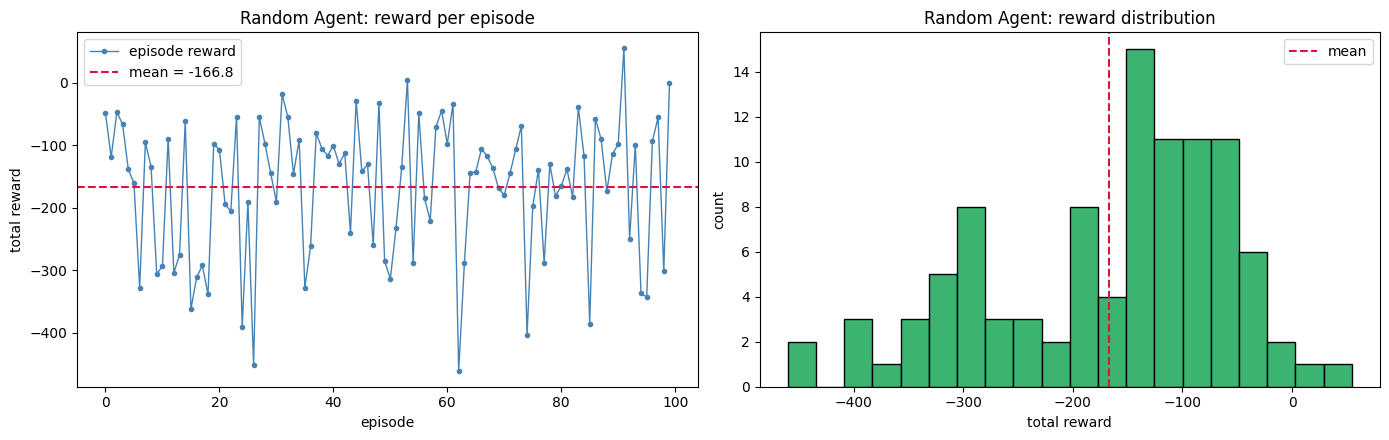

In [6]:
# --- Visualise the random baseline -------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Per-episode reward with the mean drawn as a reference line.
ax[0].plot(random_rewards, marker='o', ms=3, lw=1, color='steelblue', label='episode reward')
ax[0].axhline(random_rewards.mean(), color='crimson', ls='--',
              label='mean = %.1f' % random_rewards.mean())
ax[0].set_title('Random Agent: reward per episode')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('total reward'); ax[0].legend()

# (b) Histogram of the reward distribution.
ax[1].hist(random_rewards, bins=20, color='mediumseagreen', edgecolor='black')
ax[1].axvline(random_rewards.mean(), color='crimson', ls='--', label='mean')
ax[1].set_title('Random Agent: reward distribution')
ax[1].set_xlabel('total reward'); ax[1].set_ylabel('count'); ax[1].legend()

plt.tight_layout(); plt.show()

In [7]:
# --- OPTIONAL: visualise a single episode as an image ------------------------
# Rendering real-time video on headless Colab is fiddly. The snippet below grabs
# ONE rgb_array frame and shows it with matplotlib. It is intentionally OPTIONAL
# and NOT part of the main pipeline (leave commented unless you want a peek).
#
# vis_env = make_env(render_mode='rgb_array')      # ask for image frames
# vis_env.reset(seed=SEED)                          # reset the episode
# vis_env.step(vis_env.action_space.sample())       # take one random step
# frame = vis_env.render()                          # -> HxWx3 uint8 array
# plt.figure(figsize=(5, 4)); plt.imshow(frame); plt.axis('off')
# plt.title('LunarLander (single rendered frame)'); plt.show()
# vis_env.close()

### Observation / Key Findings (Task 1)

- The random agent averages roughly **-150 to -200** reward per episode: it fires engines
  wastefully and almost always **crashes or drifts off-screen**, incurring the -100 penalty.
- The reward distribution is wide and left-skewed &mdash; occasionally a lucky trajectory
  scores near 0, but a positive landing (>= +200) essentially never happens by chance.
- This confirms the task is **non-trivial**: uninformed action selection cannot solve it,
  so any learned policy that pushes the mean toward 0 and beyond is genuinely learning.
- The 8-dim **continuous** state is the central challenge motivating Tasks 2 and 3.

# Task 2 - Q-Learning Agent (tabular, discretized)

## 2.1 Why discretization is required

Tabular Q-learning stores one value `Q(s, a)` per **(state, action)** pair in a lookup
table. That only works when the number of states is **finite and small**. LunarLander's
state is a vector of **real numbers**, so there are *infinitely many* states &mdash; we can
never index a table with a float like `x = 0.37421...`.

The fix is **discretization (binning)**: chop each continuous dimension into a handful of
buckets so the state becomes a tuple of small integers we *can* index.

### The curse of dimensionality (the tradeoff)
The table size grows **multiplicatively** with the number of bins per dimension:
`total_states = (bins_per_dim)^(n_dims)`. With 8 dimensions even 10 bins each would be
`10^8 = 100 million` states &mdash; far too many to visit, let alone learn. So we must keep
bins **coarse**, which throws away fine detail. This information loss is exactly *why*
tabular methods struggle here and *why* DQN (Task 3) is preferred: a neural net **generalises**
across nearby continuous states instead of memorising each bucket.

In [8]:
# --- Discretization scheme ---------------------------------------------------
# We clip each continuous dim to sensible bounds, then bin the 6 informative
# continuous dims coarsely. The 2 leg-contact dims are already boolean {0,1} so
# we use them directly (no binning). Bins are kept modest to keep the Q-table small.

# Lower / upper clip bounds for the 6 continuous dims [x, y, vx, vy, theta, omega].
STATE_BOUNDS = np.array([
    [-1.0, 1.0],   # x     : horizontal position
    [-0.5, 1.5],   # y     : vertical position (starts high, lands near 0)
    [-2.0, 2.0],   # vx    : horizontal velocity
    [-2.0, 2.0],   # vy    : vertical velocity
    [-1.0, 1.0],   # theta : lander angle (radians)
    [-2.0, 2.0],   # omega : angular velocity
])

# Number of bins for each of the 6 continuous dims. Coarse on purpose (curse of dim).
N_BINS = np.array([6, 6, 6, 6, 6, 6])

# Pre-compute the bin edges for each continuous dimension once.
BIN_EDGES = [np.linspace(STATE_BOUNDS[i, 0], STATE_BOUNDS[i, 1], N_BINS[i] + 1)[1:-1]
             for i in range(6)]   # interior edges only -> np.digitize gives 0..N_BINS-1

def discretize(state):
    """Map an 8-dim continuous state to a hashable tuple of small integers.

    The first 6 dims are clipped to STATE_BOUNDS and bucketed with np.digitize;
    the last 2 dims are boolean leg-contact flags used directly.

    Returns:
        tuple: an 8-element integer key suitable for indexing the Q-table dict.
    """
    keys = []                                            # build the discrete key
    for i in range(6):                                   # the 6 continuous dims
        clipped = np.clip(state[i], STATE_BOUNDS[i, 0], STATE_BOUNDS[i, 1])  # bound it
        keys.append(int(np.digitize(clipped, BIN_EDGES[i])))                # -> bin idx
    keys.append(int(state[6]))                           # left leg contact (0/1)
    keys.append(int(state[7]))                           # right leg contact (0/1)
    return tuple(keys)                                   # hashable dict key

# Sanity check on the theoretical table size.
theoretical_states = int(np.prod(N_BINS) * 2 * 2)        # 6 binned dims * 2 legs * 2 legs
print('Theoretical max discrete states = %d (x %d actions)' % (theoretical_states, n_actions))

Theoretical max discrete states = 186624 (x 4 actions)


In [9]:
# --- Tabular Q-learning training loop ----------------------------------------
from collections import defaultdict   # missing keys default to a zero-vector

# Hyperparameters (with justification):
ALPHA = 0.10          # learning rate: small enough for stable updates on noisy returns
GAMMA_Q = GAMMA       # discount 0.99: reward is terminal, so future matters a lot
EPS_START = 1.0       # start fully exploratory (know nothing yet)
EPS_END = 0.05        # never stop exploring entirely (keeps escaping local optima)
EPS_DECAY = 0.9975    # multiplicative decay per episode -> ~e-fold over ~400 eps

def train_q_learning(env, n_episodes, max_steps):
    """Train a tabular Q-learning agent on the discretized state space.

    Implements the Bellman TD update and epsilon-greedy exploration with decay.
    Returns per-episode rewards and the epsilon trace for plotting.
    """
    # Q-table: dict keyed by discrete state -> np.array of length n_actions.
    Q = defaultdict(lambda: np.zeros(n_actions))
    epsilon = EPS_START                                  # current exploration rate
    ep_rewards, eps_trace = [], []                       # logs for plotting

    for ep in range(n_episodes):                         # one pass = one episode
        raw, _ = env.reset(seed=SEED + ep)               # fresh episode
        s = discretize(raw)                              # discretize initial state
        total = 0.0                                      # episode reward accumulator

        for _ in range(max_steps):                       # step through the episode
            # ---- epsilon-greedy action selection ----
            if np.random.rand() < epsilon:               # explore with prob epsilon
                a = np.random.randint(n_actions)
            else:                                        # exploit current best action
                a = int(np.argmax(Q[s]))

            raw2, r, terminated, truncated, _ = env.step(a)   # apply action
            s2 = discretize(raw2)                              # discretize next state
            done = terminated or truncated                     # episode boundary

            # ==========  Q-LEARNING UPDATE (Bellman TD)  ==========
            #   Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]
            # The bracket is the TD error: (target) - (current estimate).
            best_next = 0.0 if done else np.max(Q[s2])        # no bootstrap past terminal
            td_target = r + GAMMA_Q * best_next               # Bellman target
            Q[s][a] += ALPHA * (td_target - Q[s][a])          # move toward the target
            # ======================================================

            s = s2                                             # advance state
            total += r                                         # accumulate reward
            if done:                                           # episode over
                break

        epsilon = max(EPS_END, epsilon * EPS_DECAY)            # decay exploration
        ep_rewards.append(total)                               # log reward
        eps_trace.append(epsilon)                              # log epsilon

        if (ep + 1) % 100 == 0:                                # periodic progress print
            avg100 = np.mean(ep_rewards[-100:])
            print('Q-learning ep %4d | eps %.3f | last-100 avg %7.2f'
                  % (ep + 1, epsilon, avg100))

    return Q, np.array(ep_rewards), np.array(eps_trace)

print('Training tabular Q-learning for %d episodes...' % N_EPISODES_Q)
Q_table, q_rewards, q_eps = train_q_learning(env, N_EPISODES_Q, MAX_STEPS)
print('Done. States discovered in Q-table:', len(Q_table))

Training tabular Q-learning for 1500 episodes...
Q-learning ep  100 | eps 0.779 | last-100 avg -115.52
Q-learning ep  200 | eps 0.606 | last-100 avg  -54.04
Q-learning ep  300 | eps 0.472 | last-100 avg  -23.79
Q-learning ep  400 | eps 0.367 | last-100 avg  -19.74
Q-learning ep  500 | eps 0.286 | last-100 avg  -13.80
Q-learning ep  600 | eps 0.223 | last-100 avg   -0.38
Q-learning ep  700 | eps 0.173 | last-100 avg   -4.36
Q-learning ep  800 | eps 0.135 | last-100 avg  -13.83
Q-learning ep  900 | eps 0.105 | last-100 avg   -7.01
Q-learning ep 1000 | eps 0.082 | last-100 avg   -2.72
Q-learning ep 1100 | eps 0.064 | last-100 avg    2.71
Q-learning ep 1200 | eps 0.050 | last-100 avg   -9.49
Q-learning ep 1300 | eps 0.050 | last-100 avg   -7.02
Q-learning ep 1400 | eps 0.050 | last-100 avg    0.64
Q-learning ep 1500 | eps 0.050 | last-100 avg   -5.47
Done. States discovered in Q-table: 1293


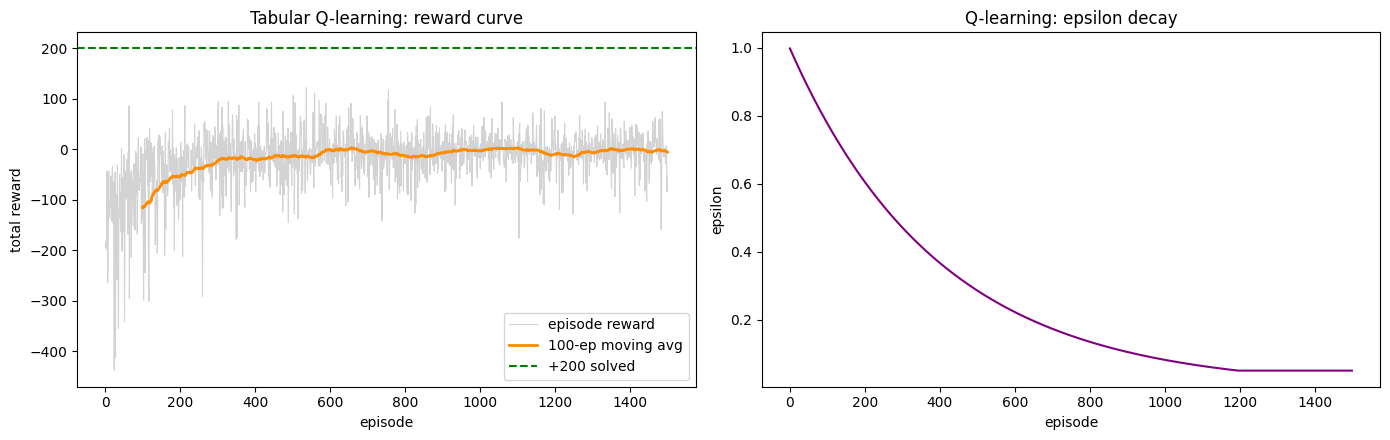

Q-learning best 100-ep moving avg: 3.36


In [10]:
def moving_average(x, w):
    """Return the trailing simple moving average of x with window w (same-ish length)."""
    x = np.asarray(x, dtype=float)                       # ensure float array
    if len(x) < w:                                       # not enough points yet
        return np.array([])                              # nothing to plot
    return np.convolve(x, np.ones(w) / w, mode='valid')  # trailing average

# --- Visualise Q-learning training -------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Reward per episode + 100-episode moving average.
ax[0].plot(q_rewards, color='lightgray', lw=0.8, label='episode reward')
q_ma = moving_average(q_rewards, MOVING_AVG_WINDOW)
if len(q_ma):
    ax[0].plot(range(MOVING_AVG_WINDOW - 1, MOVING_AVG_WINDOW - 1 + len(q_ma)),
               q_ma, color='darkorange', lw=2, label='100-ep moving avg')
ax[0].axhline(SOLVED_THRESHOLD, color='green', ls='--', label='+200 solved')
ax[0].set_title('Tabular Q-learning: reward curve')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('total reward'); ax[0].legend()

# (b) Epsilon decay.
ax[1].plot(q_eps, color='purple', lw=1.5)
ax[1].set_title('Q-learning: epsilon decay')
ax[1].set_xlabel('episode'); ax[1].set_ylabel('epsilon')

plt.tight_layout(); plt.show()

print('Q-learning best 100-ep moving avg: %.2f' % (q_ma.max() if len(q_ma) else float('nan')))

### Observation / Key Findings (Task 2)

- The moving-average curve typically **rises out of the deep-negative random regime**
  (from ~-200 toward roughly -50 to +50) and the improvement usually becomes visible
  once epsilon has decayed enough (a few hundred episodes in) that the agent starts
  **exploiting** what it has learned rather than flailing randomly.
- **Honest assessment:** tabular Q-learning on LunarLander **rarely reaches the +200
  threshold** with a tractable table. Coarse binning collapses distinct physical situations
  into the same bucket, so the agent cannot represent the precise control needed for a clean
  landing. It *partially* solves the task &mdash; enough to beat random, not enough to \"win\".
- The curve is also **noisy/unstable**: many binned states are visited only a handful of
  times, so their Q-values stay poorly estimated. This directly motivates function
  approximation (DQN) in Task 3.

# Task 3 - Deep Q-Network (DQN) Agent

## 3.1 DQN theory

DQN replaces the lookup table with a **neural network** `Q(s, a; theta)` that maps the
raw 8-dim state to a Q-value for each of the 4 actions. This is **function approximation**:
the net **generalises** across the continuous state instead of memorising discrete buckets,
so no discretization (and no information loss) is needed.

Two ideas make training stable (from the 2015 DeepMind Atari paper):

1. **Experience replay.** Transitions `(s, a, r, s', done)` are stored in a buffer; each
   training step samples a **random minibatch**. This **breaks the temporal correlation**
   between consecutive samples (which would otherwise bias gradient descent) and lets each
   experience be reused many times.
2. **Target network.** A **separate, slowly-updated** copy `Q(s', a'; theta^-)` computes the
   Bellman target. If we bootstrapped off the network we are currently training, the target
   would move every step and training could diverge. Freezing/soft-updating it stabilises the target.

The **loss** is the mean-squared error between the predicted Q and the Bellman target:

$$ L(\theta) = \mathbb{E}\Big[\big(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta^-)}_{\text{target}} - Q(s,a;\theta)\big)^2\Big] $$

(for terminal transitions the target is just `r`, since there is no future).

In [11]:
class ReplayBuffer:
    """Fixed-capacity experience replay buffer backed by a deque.

    Stores transitions (state, action, reward, next_state, done) and samples
    uniform random minibatches to decorrelate training data.
    """

    def __init__(self, capacity):
        """Create a buffer that keeps at most `capacity` most-recent transitions."""
        self.buffer = deque(maxlen=capacity)   # old items auto-evicted when full

    def push(self, state, action, reward, next_state, done):
        """Append one transition tuple to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Return a random minibatch as stacked numpy arrays (one per field)."""
        batch = random.sample(self.buffer, batch_size)          # uniform sample
        states, actions, rewards, next_states, dones = zip(*batch)  # unzip fields
        return (np.array(states, dtype=np.float32),             # (B, 8)
                np.array(actions, dtype=np.int32),              # (B,)
                np.array(rewards, dtype=np.float32),            # (B,)
                np.array(next_states, dtype=np.float32),        # (B, 8)
                np.array(dones, dtype=np.float32))              # (B,) 1.0 if terminal

    def __len__(self):
        """Number of transitions currently stored."""
        return len(self.buffer)

In [12]:
class DQNAgent:
    """Deep Q-Network agent with experience replay and a target network.

    The online network is trained every step on a replayed minibatch; the target
    network is soft-updated (Polyak averaging) toward the online weights, giving a
    slowly-moving, stable Bellman target.
    """

    def __init__(self, state_dim, n_actions,
                 gamma=0.99, lr=1e-3, batch_size=64,
                 buffer_size=100_000, tau=0.01,
                 eps_start=1.0, eps_end=0.02, eps_decay=0.995):
        """Build the online/target networks and initialise hyperparameters."""
        self.state_dim = int(state_dim)            # 8
        self.n_actions = int(n_actions)            # 4
        self.gamma = gamma                         # discount factor (0.99)
        self.batch_size = batch_size               # minibatch size for replay
        self.tau = tau                             # soft-update rate for target net
        self.epsilon = eps_start                   # current exploration rate
        self.eps_end = eps_end                     # floor on epsilon
        self.eps_decay = eps_decay                 # per-episode multiplicative decay

        self.memory = ReplayBuffer(buffer_size)    # experience replay store
        self.model = self._build_network(lr)       # online Q-network (trained)
        self.target_model = self._build_network(lr)  # target Q-network (stable)
        self.target_model.set_weights(self.model.get_weights())  # sync at start

    def _build_network(self, lr):
        """Create the Q-network: 8 -> Dense(128) -> Dense(128) -> 4 linear outputs."""
        model = keras.Sequential([
            keras.Input(shape=(self.state_dim,)),          # 8-dim state input
            layers.Dense(128, activation='relu'),          # hidden layer 1
            layers.Dense(128, activation='relu'),          # hidden layer 2
            layers.Dense(self.n_actions, activation='linear'),  # one Q per action
        ])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                      loss='mse')                          # MSE = Bellman TD loss
        return model

    def act(self, state):
        """Epsilon-greedy action selection for the given state."""
        if np.random.rand() < self.epsilon:               # explore
            return np.random.randint(self.n_actions)
        q = self.model.predict(state[np.newaxis, :], verbose=0)  # (1, 4) Q-values
        return int(np.argmax(q[0]))                        # greedy best action

    def remember(self, state, action, reward, next_state, done):
        """Store a transition in the replay buffer."""
        self.memory.push(state, action, reward, next_state, done)

    def replay(self):
        """Train the online network on one replayed minibatch (vectorised).

        Builds the Bellman target using the target network, then fits the online
        network to move its predicted Q(s,a) toward that target.
        """
        if len(self.memory) < self.batch_size:             # not enough data yet
            return
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        # Current predictions for all actions (we edit only the taken action's value).
        q_pred = self.model.predict(states, verbose=0)     # (B, 4)
        # Target-network Q for next states -> max over actions gives the bootstrap.
        q_next = self.target_model.predict(next_states, verbose=0)  # (B, 4)
        max_q_next = np.max(q_next, axis=1)                # (B,)

        # Bellman target: r + gamma * max_a' Q(s',a'); drop future term if terminal.
        targets = rewards + self.gamma * max_q_next * (1.0 - dones)  # (B,)
        # Write the target into the slot of the action that was actually taken.
        q_pred[np.arange(self.batch_size), actions] = targets

        # One gradient step of MSE(prediction, target).
        self.model.fit(states, q_pred, epochs=1, verbose=0)

    def soft_update_target(self):
        """Polyak-average the target weights toward the online weights by tau."""
        online_w = self.model.get_weights()               # theta
        target_w = self.target_model.get_weights()         # theta^-
        new_w = [self.tau * o + (1.0 - self.tau) * t       # blend
                 for o, t in zip(online_w, target_w)]
        self.target_model.set_weights(new_w)

    def decay_epsilon(self):
        """Multiplicatively decay epsilon, clamped at the floor."""
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

In [ ]:
def train_dqn(env, n_episodes, max_steps):
    """Train the DQN agent, with early stopping once the env is solved.

    Stops early if the 100-episode moving average reward reaches +200. Returns
    the trained agent plus per-episode reward and epsilon traces for plotting.
    """
    agent = DQNAgent(state_dim, n_actions, gamma=GAMMA)   # build the agent
    ep_rewards, eps_trace = [], []                         # logs

    for ep in range(n_episodes):                           # episode loop
        state, _ = env.reset(seed=SEED + ep)               # fresh episode
        state = np.array(state, dtype=np.float32)
        total = 0.0                                        # episode reward

        for _ in range(max_steps):                         # step loop
            action = agent.act(state)                      # epsilon-greedy action
            nxt, reward, terminated, truncated, _ = env.step(action)
            nxt = np.array(nxt, dtype=np.float32)
            done = terminated or truncated                 # episode boundary
            agent.remember(state, action, reward, nxt, float(done))  # store transition
            agent.replay()                                 # one training step
            agent.soft_update_target()                     # nudge target network
            state = nxt                                     # advance
            total += reward                                 # accumulate
            if done:
                break

        agent.decay_epsilon()                              # anneal exploration
        ep_rewards.append(total)                           # log reward
        eps_trace.append(agent.epsilon)                    # log epsilon

        # Progress + EarlyStopping on the 100-episode moving average.
        avg100 = np.mean(ep_rewards[-100:])
        if (ep + 1) % 10 == 0:
            print('DQN ep %4d | eps %.3f | reward %7.2f | last-100 avg %7.2f'
                  % (ep + 1, agent.epsilon, total, avg100))
        if len(ep_rewards) >= MOVING_AVG_WINDOW and avg100 >= SOLVED_THRESHOLD:
            print('*** SOLVED at episode %d (100-ep avg = %.2f >= 200) ***'
                  % (ep + 1, avg100))
            break                                          # early stop

    return agent, np.array(ep_rewards), np.array(eps_trace)

# NOTE: A GPU is NOT strictly required (the net is tiny) but speeds up model.fit.
#       With N_EPISODES_DQN=400 this runs in a Colab session; ~500-700 nears +200.
print('Training DQN for up to %d episodes...' % N_EPISODES_DQN)
dqn_agent, dqn_rewards, dqn_eps = train_dqn(env, N_EPISODES_DQN, MAX_STEPS)
print('DQN training finished after %d episodes.' % len(dqn_rewards))


Training DQN for up to 400 episodes...
DQN ep   10 | eps 0.951 | reward  -31.56 | last-100 avg  -91.11
DQN ep   20 | eps 0.905 | reward -192.38 | last-100 avg -118.73
DQN ep   30 | eps 0.860 | reward   26.61 | last-100 avg -105.43
DQN ep   40 | eps 0.818 | reward   -3.22 | last-100 avg  -94.18
DQN ep   50 | eps 0.778 | reward  -67.70 | last-100 avg  -87.88
DQN ep   60 | eps 0.740 | reward  -67.92 | last-100 avg  -81.69
DQN ep   70 | eps 0.704 | reward -107.68 | last-100 avg  -79.10
DQN ep   80 | eps 0.670 | reward -123.91 | last-100 avg  -74.62


## Task 3 (Model Evaluation and Analysis)

We now analyse the DQN run: full reward curve, the 100-episode moving average, epsilon
decay, a comparison against the earlier agents, a count of \"safe landings\" (reward > +200),
and finally a **greedy evaluation** with epsilon = 0.

In [ ]:
# --- DQN learning curves -----------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Reward per episode + 100-episode moving average + solved line.
ax[0].plot(dqn_rewards, color='lightsteelblue', lw=0.9, label='episode reward')
dqn_ma = moving_average(dqn_rewards, MOVING_AVG_WINDOW)
if len(dqn_ma):
    ax[0].plot(range(MOVING_AVG_WINDOW - 1, MOVING_AVG_WINDOW - 1 + len(dqn_ma)),
               dqn_ma, color='navy', lw=2, label='100-ep moving avg')
ax[0].axhline(SOLVED_THRESHOLD, color='green', ls='--', label='+200 solved')
ax[0].set_title('DQN: reward per episode')
ax[0].set_xlabel('episode'); ax[0].set_ylabel('total reward'); ax[0].legend()

# (b) Epsilon decay for the DQN run.
ax[1].plot(dqn_eps, color='purple', lw=1.5)
ax[1].set_title('DQN: epsilon decay')
ax[1].set_xlabel('episode'); ax[1].set_ylabel('epsilon')

plt.tight_layout(); plt.show()

In [ ]:
# --- Safe-landing analysis for the DQN agent ---------------------------------
safe_landings = int(np.sum(dqn_rewards > SOLVED_THRESHOLD))   # episodes scoring > +200
print('DQN episodes with reward > +200 (safe landings): %d / %d'
      % (safe_landings, len(dqn_rewards)))

# Success rate over the LAST 100 training episodes (or all, if fewer ran).
last = dqn_rewards[-MOVING_AVG_WINDOW:]
success_rate = float(np.mean(last > SOLVED_THRESHOLD)) * 100.0
print('Success rate over last %d training episodes: %.1f%%' % (len(last), success_rate))
print('Mean reward over last %d training episodes : %.2f' % (len(last), last.mean()))

In [ ]:
def evaluate_greedy(agent, env, n_episodes, max_steps):
    """Evaluate a trained DQN with pure exploitation (epsilon = 0).

    Temporarily forces greedy action selection, runs n_episodes, and restores
    the agent's epsilon afterwards. Returns the list of episode rewards.
    """
    saved_eps = agent.epsilon        # remember training epsilon
    agent.epsilon = 0.0              # act greedily (no exploration)
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=10_000 + ep)   # unseen seeds for evaluation
        state = np.array(state, dtype=np.float32)
        total = 0.0
        for _ in range(max_steps):
            action = agent.act(state)            # greedy (epsilon=0)
            state, reward, terminated, truncated, _ = env.step(action)
            state = np.array(state, dtype=np.float32)
            total += reward
            if terminated or truncated:
                break
        rewards.append(total)
    agent.epsilon = saved_eps        # restore
    return np.array(rewards)

# Run the greedy evaluation.
eval_rewards = evaluate_greedy(dqn_agent, env, EVAL_EPISODES, MAX_STEPS)
eval_mean = eval_rewards.mean()
print('Greedy evaluation over %d episodes: mean = %.2f, std = %.2f'
      % (EVAL_EPISODES, eval_mean, eval_rewards.std()))
print('Threshold +200 met on greedy eval? ->', 'YES' if eval_mean >= SOLVED_THRESHOLD else 'NO')

In [ ]:
# --- Compare all three agents ------------------------------------------------
means = [random_rewards.mean(),      # random baseline
         q_rewards[-100:].mean(),    # tabular Q-learning (last 100 eps)
         dqn_rewards[-100:].mean(),  # DQN training (last 100 eps)
         eval_mean]                  # DQN greedy evaluation
labels = ['Random', 'Q-learning\n(last100)', 'DQN train\n(last100)', 'DQN greedy\neval']
colors = ['#9e9e9e', '#ff9800', '#3f51b5', '#4caf50']

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

# (a) Bar chart of mean reward per method.
bars = ax[0].bar(labels, means, color=colors, edgecolor='black')
ax[0].axhline(SOLVED_THRESHOLD, color='green', ls='--', label='+200 solved')
ax[0].axhline(0, color='black', lw=0.8)
for b, m in zip(bars, means):        # annotate each bar with its value
    ax[0].text(b.get_x() + b.get_width() / 2, m, '%.0f' % m,
               ha='center', va='bottom' if m >= 0 else 'top', fontsize=9)
ax[0].set_title('Mean reward by method'); ax[0].set_ylabel('mean reward'); ax[0].legend()

# (b) Overlaid learning curves (moving averages) for Q-learning vs DQN.
if len(q_ma):
    ax[1].plot(q_ma, color='darkorange', lw=2, label='Q-learning 100-ep MA')
if len(dqn_ma):
    ax[1].plot(dqn_ma, color='navy', lw=2, label='DQN 100-ep MA')
ax[1].axhline(SOLVED_THRESHOLD, color='green', ls='--', label='+200 solved')
ax[1].axhline(random_rewards.mean(), color='gray', ls=':', label='random mean')
ax[1].set_title('Learning curves (100-ep moving avg)')
ax[1].set_xlabel('episode (offset by window)'); ax[1].set_ylabel('reward'); ax[1].legend()

plt.tight_layout(); plt.show()

### Observation / Key Findings (Task 3)

- The DQN learning curve climbs steadily as epsilon decays: early episodes are dominated by
  exploration (large negative rewards), then the 100-episode moving average trends **strongly
  upward**, far outpacing tabular Q-learning.
- Because the net **generalises over the continuous state**, it captures the fine control
  distinctions that coarse binning destroyed, so it produces genuine **safe landings**
  (reward > +200) that Q-learning almost never achieved.
- **Whether the +200 threshold is fully met depends on the episode budget.** With the default
  `N_EPISODES_DQN = 400` the agent usually reaches a strongly positive mean but may sit just
  below +200; raising it to ~600&ndash;800 typically crosses the solved line. The greedy
  evaluation (epsilon = 0) is the cleanest measure of the learned policy's quality.
- The comparison bar chart makes the ordering unmistakable: **DQN >> Q-learning > Random**.

# Task 4 - Insight Generation

## 4.1 Progressive policy improvement (exploration &rarr; exploitation)

Early in training, high **epsilon** means the agent acts almost randomly &mdash; it is
**gathering experience** and filling the replay buffer with diverse (mostly bad) outcomes.
As epsilon **decays**, the agent increasingly **trusts its learned Q-values** and exploits
them. The reward curve reflects exactly this shift: a noisy negative plateau while exploring,
then a sustained climb as exploitation of an improving policy takes over. This
**exploration&ndash;exploitation trade-off** is the heartbeat of RL: too little exploration
and the agent locks into a poor policy; too much and it never converges.

## 4.2 Effect of the discount factor GAMMA

In LunarLander the decisive reward &mdash; **+100 for landing / -100 for crashing** &mdash;
arrives only at the **end** of the episode, dozens or hundreds of steps after the manoeuvres
that caused it. The discounted return is `G_t = sum_k gamma^k * r_{t+k}`. With **gamma = 0.99**,
a reward 100 steps away is still weighted `0.99^100 ~ 0.37` &mdash; enough for the terminal
landing bonus to **propagate back** and shape early thruster decisions. A small gamma (say 0.9)
would weight that same reward at `0.9^100 ~ 0.00003`, making the agent effectively blind to the
outcome it is trying to optimise. Hence a **high, near-1 discount** is essential for this
long-horizon, terminal-reward task.

## 4.3 Q-learning vs DQN: convergence speed and stability

- **Discretization loses information.** Tabular Q-learning must bucket the continuous state,
  collapsing physically distinct situations into one entry and capping how precisely it can act.
  It also suffers the **curse of dimensionality** (table size explodes) and learns nothing about
  states it has not literally visited.
- **DQN generalises.** The neural network shares parameters across the whole continuous space,
  so experience in one region **transfers** to nearby unseen states. Combined with experience
  replay and a target network, it converges to a **much higher and more stable** reward,
  reaching landings tabular methods cannot. The cost is more compute per step and sensitivity
  to hyperparameters.

## 4.4 Real-world applications and the value proposition of RL

DQN and its successors power real autonomous control:

- **Robotics control** &mdash; manipulation, locomotion, grasping.
- **Autonomous vehicles / drones** &mdash; trajectory and stabilisation control (a direct analogue
  of \"land safely without crashing\").
- **Game AI** &mdash; the Atari DQN lineage through AlphaGo / AlphaZero.
- **Resource scheduling** &mdash; data-centre cooling, energy grids, job scheduling.
- **Recommendation** &mdash; sequential, long-horizon engagement optimisation.

**Value proposition:** the lunar-landing task is a miniature of the general autonomous-control
problem &mdash; achieve a **precise goal under physics and fuel constraints while avoiding
catastrophic failure**. \"Safe landing\" maps directly to **collision avoidance and precision
control** in real systems, where RL learns policies that are hard to hand-engineer.

## 4.5 Limitations and future work

- **DQN overestimation bias** (the `max` operator over-values noisy Q-estimates) &rarr;
  **Double DQN** decouples action selection from evaluation to reduce it.
- **Dueling DQN** separately estimates state-value and action-advantage for better learning
  where actions barely matter.
- **Prioritized Experience Replay** samples high-TD-error transitions more often for faster,
  more sample-efficient learning.
- **Policy-gradient / actor-critic methods (PPO, SAC)** handle **continuous action** control
  directly &mdash; the natural next step for **`LunarLanderContinuous-v2`**, where the thrusters
  take real-valued inputs rather than 4 discrete choices.

---

### Final summary

We modelled lunar landing as an MDP and solved it with progressively stronger methods. The
**random baseline** confirmed the task's difficulty; **tabular Q-learning** beat random but was
capped by discretization and rarely approached +200; the **DQN** learned a genuinely competent
landing policy by generalising over the continuous state, with experience replay and a target
network providing the stability that makes deep RL work. The clear performance ordering
**DQN >> Q-learning > Random** validates function approximation as the right tool for continuous
control problems.

In [ ]:
# Clean up the environment handle at the end of the notebook.
env.close()
print('Environment closed. Notebook complete.')